SIDDHANT CHAUHAN       
           LAB SHEET 9   
                          COMPUTER VISION

In [1]:
pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 7.3 MB/s eta 0:00:00


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from ultralytics import YOLO
print("Libraries imported successfully!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Libraries imported successfully!


In [3]:
# Load pre-trained YOLOv8 model
model = YOLO("yolov8n.pt")
print("YOLOv8 model loaded successfully!")

YOLOv8 model loaded successfully!


In [4]:
from ultralytics.utils.downloads import download
# Download sample images
download(
    "https://ultralytics.com/images/bus.jpg",
    dir="."
)
download(
    "https://ultralytics.com/images/zidane.jpg",
    dir="."
)
print("Sample images downloaded.")

Sample images downloaded.


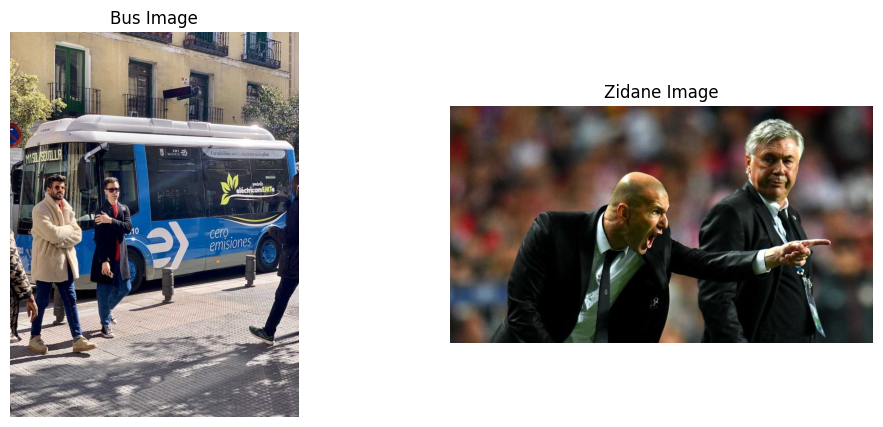

In [5]:
img1 = cv2.imread("bus.jpg")
img2 = cv2.imread("zidane.jpg")

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title("Bus Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title("Zidane Image")
plt.axis("off")

plt.show()


Original shape: (1080, 810, 3)
Processed shape: (640, 640, 3)


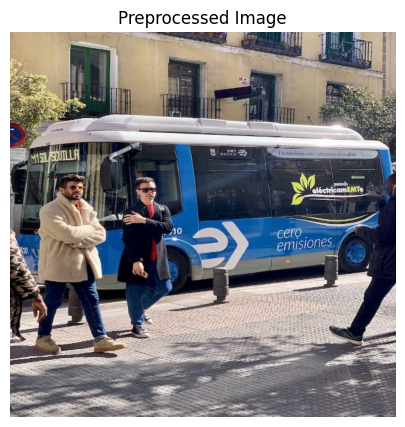

In [6]:
def preprocess_image(image_path, size=(640, 640)):
    image = cv2.imread(image_path)

    if image is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    # Resize image
    resized = cv2.resize(image, size)

    return resized


processed_img = preprocess_image("bus.jpg")

print("Original shape:", img1.shape)
print("Processed shape:", processed_img.shape)

plt.figure(figsize=(7,5))
plt.imshow(cv2.cvtColor(processed_img, cv2.COLOR_BGR2RGB))
plt.title("Preprocessed Image")
plt.axis("off")
plt.show()


In [7]:
# Run object detection
results = model("bus.jpg")
print("Object detection completed.")


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 6.4ms
Speed: 99.9ms preprocess, 6.4ms inference, 37.7ms postprocess per image at shape (1, 3, 640, 480)
Object detection completed.


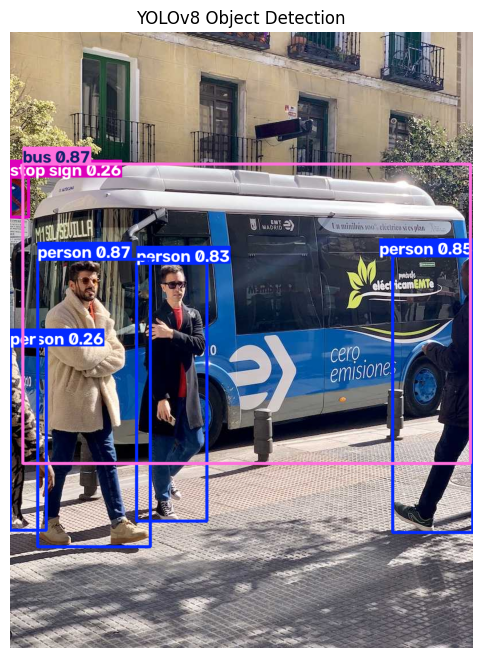

In [8]:
# Display detection result
result_image = results[0].plot()
plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.title("YOLOv8 Object Detection")
plt.axis("off")
plt.show()


In [9]:
result = results[0]

detections = []

for box in result.boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    coordinates = box.xyxy[0].cpu().numpy()

    x1, y1, x2, y2 = coordinates

    detections.append({
        "Object": model.names[class_id],
        "Confidence": round(confidence, 3),
        "X1": round(float(x1), 2),
        "Y1": round(float(y1), 2),
        "X2": round(float(x2), 2),
        "Y2": round(float(y2), 2)
    })

detection_df = pd.DataFrame(detections)

detection_df


,Object,Confidence,X1,Y1,X2,Y2
0,bus,0.873,22.87,231.28,805.00,756.84
1,person,0.866,48.55,398.55,245.35,902.70
2,person,0.853,669.47,392.19,809.72,877.04
3,person,0.825,221.52,405.80,344.97,857.54
4,person,0.261,0.00,550.53,63.01,873.44
5,stop sign,0.255,0.06,254.46,32.56,324.87


In [10]:
confidence_threshold = 0.50

valid_detections = detection_df[
    detection_df["Confidence"] >= confidence_threshold
]

low_confidence = detection_df[
    detection_df["Confidence"] < confidence_threshold
]

print("Total detections:", len(detection_df))
print("High-confidence detections:", len(valid_detections))
print("Low-confidence detections:", len(low_confidence))

print("\nDetected objects:")
print(valid_detections[["Object", "Confidence"]])


Total detections: 6
High-confidence detections: 4
Low-confidence detections: 2

Detected objects:
   Object  Confidence
0     bus       0.873
1  person       0.866
2  person       0.853
3  person       0.825


In [11]:
# Validate YOLOv8 on COCO8
metrics = model.val(data="coco8.yaml", imgsz=640)
print("Validation completed.")

Ultralytics 8.4.160 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

WARNING ⚠️ Dataset 'coco8.yaml' images not found, missing path '/content/datasets/coco8/images/val'
Unzipping /content/datasets/coco8.zip to /content/datasets/coco8...: 100% ━━━━━━━━━━━━ 25/25 2.9Kfiles/s 0.0s
Dataset download success ✅ (0.1s), saved to /content/datasets

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1174.6±398.0 MB/s, size: 54.0 KB)
val: Scanning /content/datasets/coco8/labels/val... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 1.4Kit/s 0.0s
val: New cache created: /content/datasets/coco8/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 5.5it/s 0.2s
                   all          4         17      0.621      0.833      0.888      0.629
                person          3         10      0.721        0.5      0

In [12]:
print("mAP50-95 :", metrics.box.map)
print("mAP50    :", metrics.box.map50)
print("mAP75    :", metrics.box.map75)

mAP50-95 : 0.6290666933218909
mAP50    : 0.8875131975867271
mAP75    : 0.6346575670498085



image 1/1 /content/zidane.jpg: 384x640 2 persons, 1 tie, 51.3ms
Speed: 1.4ms preprocess, 51.3ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


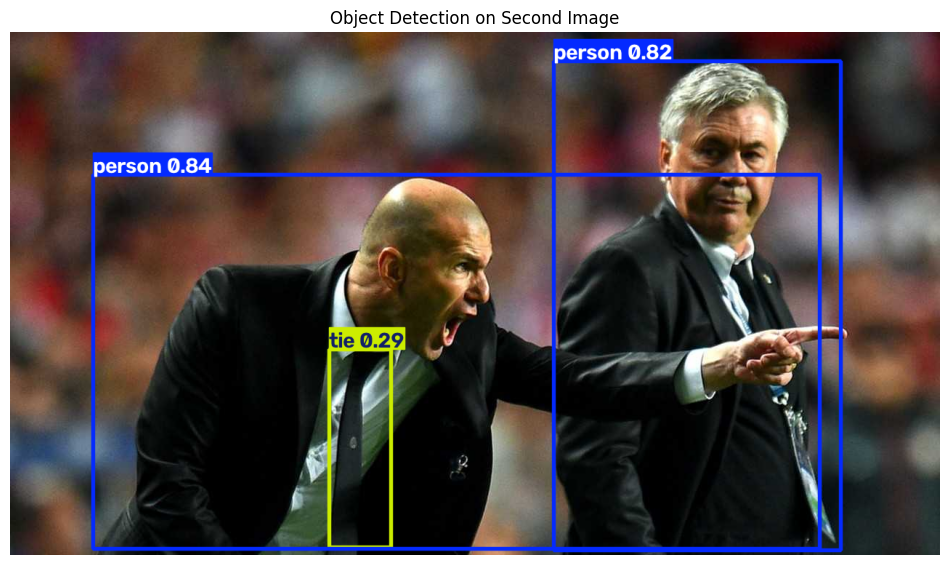

In [13]:
results2 = model("zidane.jpg")

result_image2 = results2[0].plot()

plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(result_image2, cv2.COLOR_BGR2RGB))
plt.title("Object Detection on Second Image")
plt.axis("off")
plt.show()

In [14]:
result2 = results2[0]

detections2 = []

for box in result2.boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    detections2.append({
        "Object": model.names[class_id],
        "Confidence": round(confidence, 3)
    })

pd.DataFrame(detections2)


,Object,Confidence
0,person,0.836
1,person,0.819
2,tie,0.291


In [15]:
# Load two YOLOv8 models
model_n = YOLO("yolov8n.pt")
model_s = YOLO("yolov8s.pt")

print("Both models loaded.")

Both models loaded.


In [16]:
def measure_inference_time(model, image_path):
    start = time.time()
    result = model(image_path, verbose=False)
    end = time.time()

    return end - start, result


time_n, result_n = measure_inference_time(model_n, "bus.jpg")
time_s, result_s = measure_inference_time(model_s, "bus.jpg")

comparison = pd.DataFrame({
    "Model": ["YOLOv8n", "YOLOv8s"],
    "Inference Time (seconds)": [time_n, time_s],
    "Objects Detected": [
        len(result_n[0].boxes),
        len(result_s[0].boxes)
    ]
})

comparison


,Model,Inference Time (seconds),Objects Detected
0,YOLOv8n,0.181948,6
1,YOLOv8s,0.163944,5


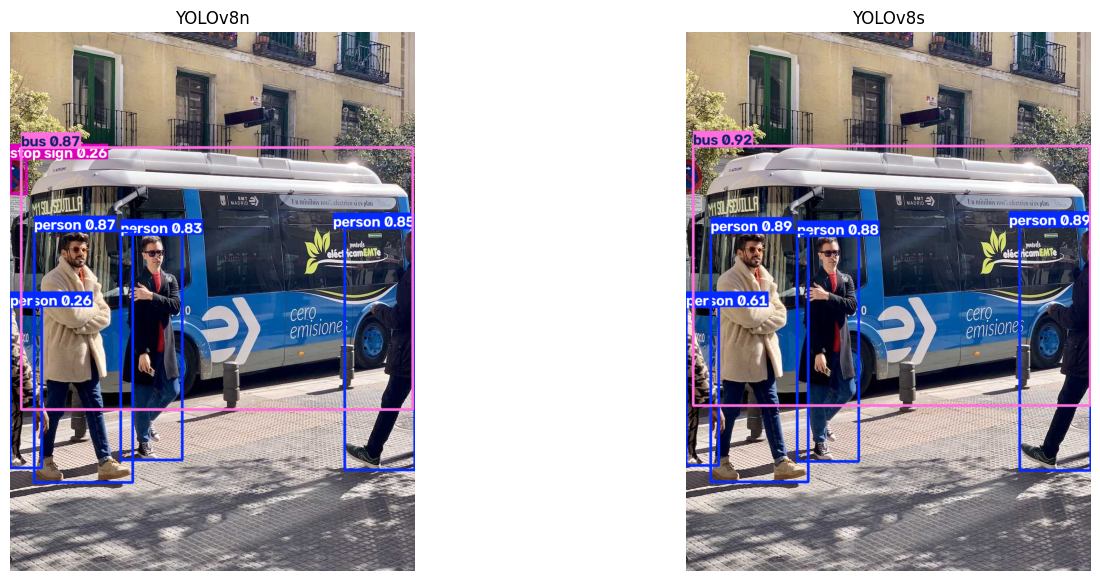

In [17]:
plt.figure(figsize=(16,7))

plt.subplot(1,2,1)
plt.imshow(
    cv2.cvtColor(result_n[0].plot(), cv2.COLOR_BGR2RGB)
)
plt.title("YOLOv8n")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(
    cv2.cvtColor(result_s[0].plot(), cv2.COLOR_BGR2RGB)
)
plt.title("YOLOv8s")
plt.axis("off")

plt.show()


In [18]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

print("Uploaded image:", image_path)


Saving IMG-20250803-WA0006.jpg to IMG-20250803-WA0006.jpg
Uploaded image: IMG-20250803-WA0006.jpg



image 1/1 /content/IMG-20250803-WA0006.jpg: 448x640 1 person, 1 tie, 46.9ms
Speed: 1.9ms preprocess, 46.9ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)


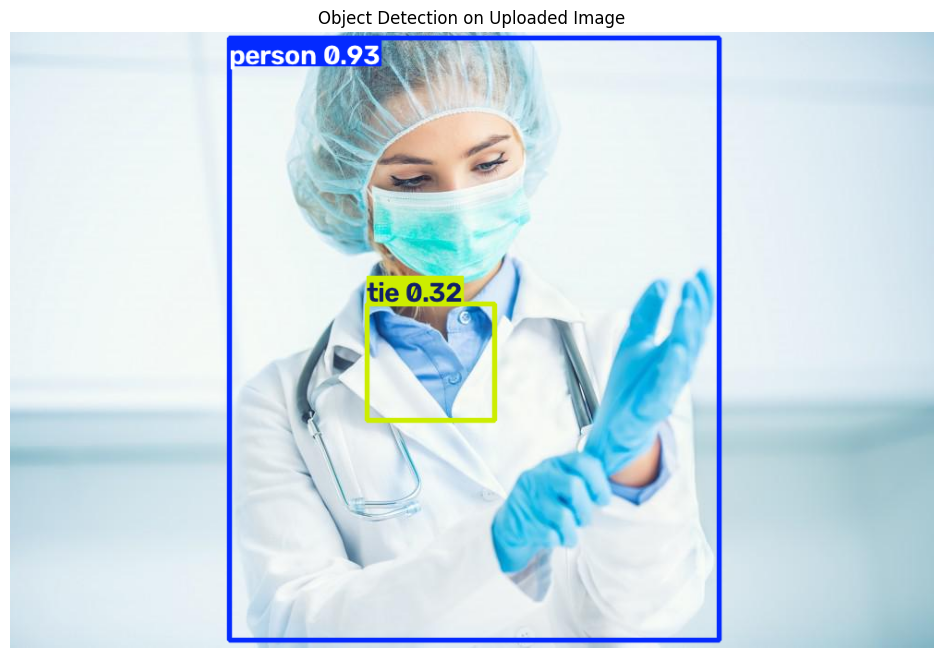

In [19]:
results_uploaded = model(image_path)

annotated = results_uploaded[0].plot()

plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title("Object Detection on Uploaded Image")
plt.axis("off")
plt.show()


In [20]:
uploaded_detections = []

for box in results_uploaded[0].boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

    uploaded_detections.append({
        "Object": model.names[class_id],
        "Confidence": round(confidence, 3),
        "X1": round(float(x1), 2),
        "Y1": round(float(y1), 2),
        "X2": round(float(x2), 2),
        "Y2": round(float(y2), 2)
    })

pd.DataFrame(uploaded_detections)


,Object,Confidence,X1,Y1,X2,Y2
0,person,0.930,237.0,6.09,767.61,658.16
1,tie,0.316,387.0,294.09,524.44,420.87
